# Hiring & Selection Pipeline Analytics — Workflow

This notebook runs the selection-pipeline analysis end to end: it loads the synthetic
candidate tables into an in-memory SQLite database, runs the project's SQL to compute
funnel counts, subgroup selection (pass) rates, and an adverse-impact screen against the
4/5ths rule, and renders the three figures inline.

All data here is **synthetic** (generated by `data/generate_data.py`); it contains no real
candidate records. The companion `02_Project_Report.md` carries the full method and metric
definitions, citations, and interpretation — this notebook is the executable trail behind it.

In [1]:
# Load the synthetic CSV tables into an in-memory SQLite database and run the project
# schema. Using SQLite keeps the analysis SQL-first and dependency-light: the same queries
# that ship in sql/ are executed here without modification, so the notebook and the
# script-based run can never drift apart.
import sqlite3, csv
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd()                      # notebook is executed from the project folder
DATA, SQLDIR = ROOT/"data", ROOT/"sql"

conn = sqlite3.connect(":memory:")
conn.executescript((SQLDIR/"01_schema.sql").read_text())

def load(table):
    # Factor each CSV into its schema-defined table. Loading through the schema (rather than
    # pandas to_sql) preserves the column types declared in 01_schema.sql.
    with (DATA/f"{table}.csv").open(newline="") as f:
        r = csv.reader(f); header = next(r); rows = list(r)
    ph = ",".join("?"*len(header))
    conn.executemany(f"INSERT INTO {table} ({','.join(header)}) VALUES ({ph})", rows)

for t in ["candidates","assessments","pipeline_events","outcomes"]:
    load(t)
conn.commit()
print("Loaded tables:", ["candidates","assessments","pipeline_events","outcomes"])

Loaded tables: ['candidates', 'assessments', 'pipeline_events', 'outcomes']


## 1. Funnel: where the pipeline loses candidates

The funnel counts distinct candidates at each stage. The stage-to-stage conversion rate — each
count divided by the prior stage's count — isolates how strong each individual gate is.

In [2]:
# Run the committed funnel query and compute stage-to-stage conversion so we can see which
# single gate filters the most candidates (not just the cumulative yield).
funnel = pd.read_sql_query((SQLDIR/"02_funnel_metrics.sql").read_text(), conn)
funnel["conversion_from_prior"] = (funnel["candidates"] / funnel["candidates"].shift(1)).round(3)
funnel

,stage_order,stage,candidates,conversion_from_prior
0,1,applied,5000,NaN
1,2,screen,5000,1.000
2,3,assessment,2363,0.473
3,4,interview,1070,0.453
4,5,offer,678,0.634
5,6,hire,434,0.640


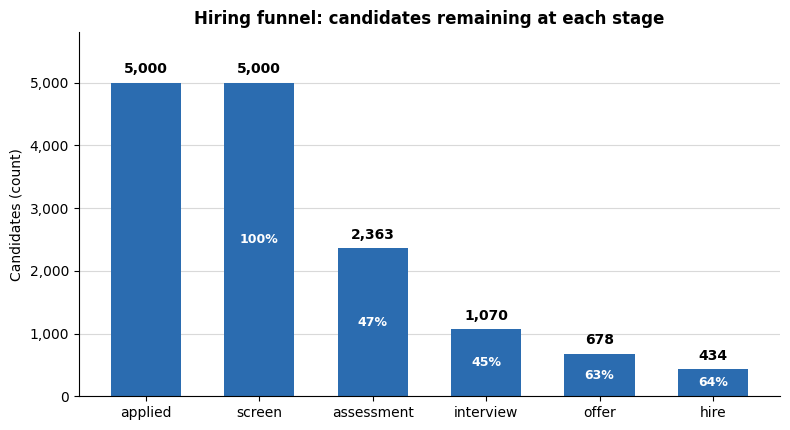

In [3]:
# Plot the funnel with conversion labels. Title, axis label, thousands formatting, and a
# minimal theme keep it readable as a standalone artifact.
fig, ax = plt.subplots(figsize=(8,4.4))
bars = ax.bar(funnel["stage"], funnel["candidates"], color="#2b6cb0", width=0.62)
ax.set_title("Hiring funnel: candidates remaining at each stage", fontweight="bold")
ax.set_ylabel("Candidates (count)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.set_ylim(0, funnel["candidates"].max()*1.16)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.yaxis.grid(True, color="#d9d9d9"); ax.set_axisbelow(True)
for i,(b,n) in enumerate(zip(bars, funnel["candidates"])):
    ax.text(b.get_x()+b.get_width()/2, n+funnel["candidates"].max()*0.02, f"{n:,}",
            ha="center", va="bottom", fontweight="bold", fontsize=10)
    c = funnel["conversion_from_prior"].iloc[i]
    if pd.notna(c):
        ax.text(b.get_x()+b.get_width()/2, n/2, f"{c:.0%}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=9)
plt.tight_layout(); plt.show()

Every applicant is screened, but only **47%** advance past the assessment and **45%** past the
interview, while the offer and hire gates pass roughly two-thirds each. The assessment and interview
gates do the bulk of the filtering — that is where both efficiency and fairness review should start.

## 2. Subgroup selection (pass) rates

The selection ratio is a group's passes divided by the candidates from that group who reached the
stage, computed separately by race/ethnicity. Computing it per stage (not just end-to-end) is what
lets a single divergent gate show up.

In [4]:
# Pull the adverse-impact table (which already carries per-group pass rates) and pivot
# race/ethnicity pass rates across the evaluative stages for a compact comparison.
ai = pd.read_sql_query((SQLDIR/"04_adverse_impact_screen.sql").read_text(), conn)
stages = ["screen","assessment","interview","offer","hire"]
groups = ["Asian","Black","Hispanic/Latino","Two+","Unknown","White"]
race = ai[(ai.dimension=="race_ethnicity_group") & (ai.stage.isin(stages))]
pivot = race.pivot_table(index="stage", columns="group_name", values="pass_rate").reindex(stages)[groups]
pivot.round(3)

group_name,Asian,Black,Hispanic/Latino,Two+,Unknown,White
stage,,,,,,
screen,0.482,0.507,0.458,0.406,0.476,0.473
assessment,0.426,0.356,0.412,0.506,0.446,0.478
interview,0.669,0.629,0.646,0.667,0.676,0.616
offer,0.673,0.641,0.742,0.633,0.660,0.613
hire,0.569,0.400,0.565,0.368,0.576,0.540


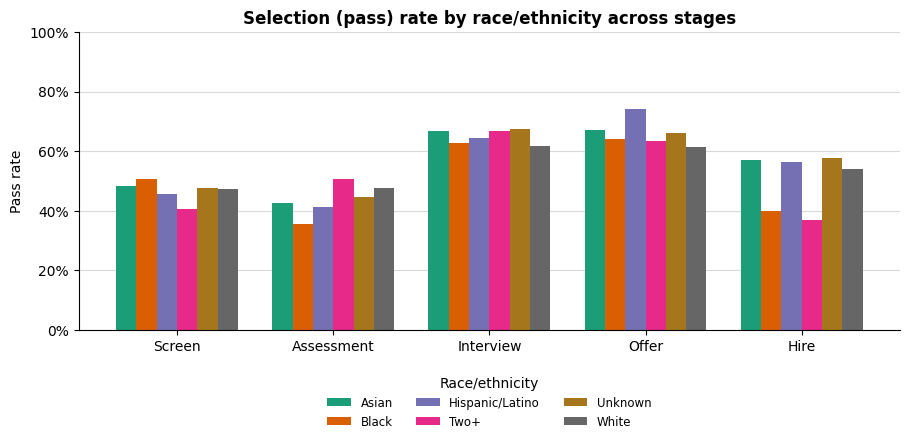

In [5]:
# Grouped bars make the within-stage spread visible. The screen/interview/offer clusters sit in
# tight bands; the assessment cluster shows the widest separation.
palette = ["#1b9e77","#d95f02","#7570b3","#e7298a","#a6761d","#666666"]
fig, ax = plt.subplots(figsize=(9.2,4.6)); w=0.13; x=range(len(stages))
for j,(g,c) in enumerate(zip(groups,palette)):
    ax.bar([i+(j-2.5)*w for i in x], pivot[g].values, width=w, label=g, color=c)
ax.set_title("Selection (pass) rate by race/ethnicity across stages", fontweight="bold")
ax.set_ylabel("Pass rate"); ax.set_ylim(0,1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_xticks(list(x)); ax.set_xticklabels([s.capitalize() for s in stages])
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.yaxis.grid(True, color="#d9d9d9"); ax.set_axisbelow(True)
ax.legend(title="Race/ethnicity", ncol=3, fontsize=8.5, loc="upper center",
          bbox_to_anchor=(0.5,-0.12), frameon=False)
plt.tight_layout(); plt.show()

At the assessment gate the **Black** group passes at 35.6% against 50.6% for the top group — a
12-to-15-point gap wider than anything at the other early gates. The hire cluster dips too, but on
much smaller counts (handled next).

## 3. Adverse-impact screen (4/5ths rule)

Each group's pass rate is divided by the highest group's pass rate at the stage. A ratio below
**0.80** flags for review. The rule ignores sample size, so small cells are read as provisional.

In [6]:
# Surface the flagged rows and attach the candidate count, which is decisive for how much weight
# each flag carries. The assessment flag (n=174) is robust; the hire flags (n<30) are not.
flagged = ai[ai.flagged_under_4_5ths==1][["dimension","stage","group_name","n_total","pass_rate","impact_ratio"]]
flagged.sort_values(["dimension","stage"]).reset_index(drop=True)

,dimension,stage,group_name,n_total,pass_rate,impact_ratio
0,gender_group,hire,Nonbinary/Other,17,0.3529,0.6265
1,race_ethnicity_group,assessment,Black,174,0.3563,0.7047
2,race_ethnicity_group,hire,Black,25,0.4000,0.6947
3,race_ethnicity_group,hire,Two+,19,0.3684,0.6399


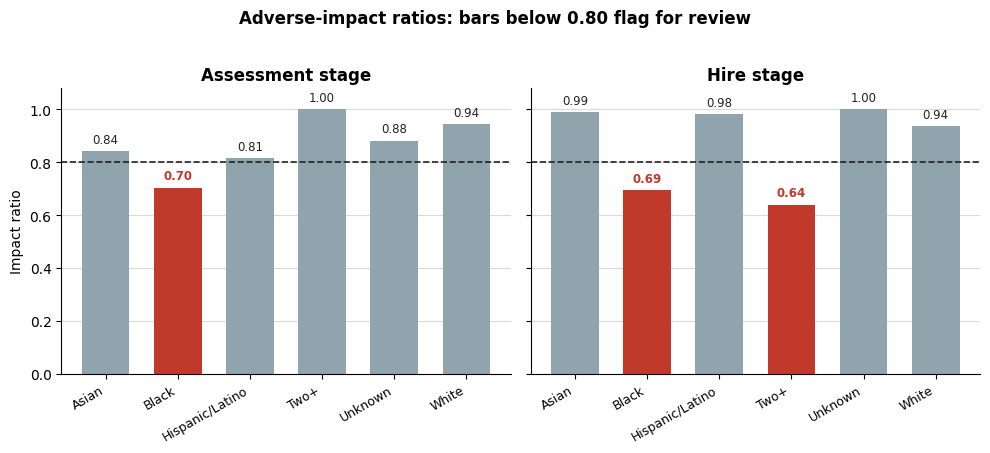

In [7]:
# Impact ratios at the two flagging stages, with the 0.80 line and below-threshold bars colored
# to mark the review trigger.
fig, axes = plt.subplots(1,2, figsize=(10,4.4), sharey=True)
for axx, stage in zip(axes, ["assessment","hire"]):
    sub = race[race.stage==stage].set_index("group_name").reindex(groups)
    r = sub["impact_ratio"].values
    cols = ["#c0392b" if v<0.8 else "#90a4ae" for v in r]
    axx.bar(groups, r, color=cols, width=0.66)
    axx.axhline(0.8, color="#222", ls="--", lw=1.2)
    axx.set_title(f"{stage.capitalize()} stage", fontweight="bold"); axx.set_ylim(0,1.08)
    axx.set_xticks(range(len(groups))); axx.set_xticklabels(groups, rotation=30, ha="right", fontsize=9)
    for sp in ["top","right"]: axx.spines[sp].set_visible(False)
    axx.yaxis.grid(True, color="#d9d9d9"); axx.set_axisbelow(True)
    for i,v in enumerate(r):
        axx.text(i, v+0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=8.5,
                 color="#c0392b" if v<0.8 else "#222", fontweight="bold" if v<0.8 else "normal")
axes[0].set_ylabel("Impact ratio")
fig.suptitle("Adverse-impact ratios: bars below 0.80 flag for review", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## 4. Do the flags survive a significance test?

The 4/5ths rule ignores sample size. For each flagged cell we add a two-proportion z-test against the
stage's top group and a 95% confidence interval on the impact ratio. A flag whose interval excludes
1.00 (parity) reflects a real difference; one whose interval spans 1.00 does not.

In [8]:
# Two-proportion z-test and a log-scale 95% CI on the impact ratio for each flagged cell.
# Implemented with math.erfc so the notebook needs no SciPy.
import math
from collections import defaultdict
def norm_sf(z): return 0.5*math.erfc(z/math.sqrt(2))
cells_by=defaultdict(list)
for _,r in ai.iterrows():
    cells_by[(r.dimension,r.stage)].append(r)
rows=[]
for (dim,stage),rs in cells_by.items():
    if stage=="applied": continue
    top=max(rs,key=lambda x:x.pass_rate)
    x2,n2,p2=int(top.n_passed),int(top.n_total),float(top.pass_rate)
    for r in rs:
        if r.group_name==top.group_name or int(r.flagged_under_4_5ths)!=1 or r.pass_rate==0: continue
        x1,n1,p1=int(r.n_passed),int(r.n_total),float(r.pass_rate)
        pp=(x1+x2)/(n1+n2); se=math.sqrt(pp*(1-pp)*(1/n1+1/n2))
        z=(p1-p2)/se; pval=2*norm_sf(abs(z)); ir=p1/p2
        sl=math.sqrt((1-p1)/(p1*n1)+(1-p2)/(p2*n2))
        lo,hi=math.exp(math.log(ir)-1.96*sl),math.exp(math.log(ir)+1.96*sl)
        rows.append(dict(dimension=dim,stage=stage,group=r.group_name,n=n1,
                         impact_ratio=round(ir,3),ci_low=round(lo,3),ci_high=round(hi,3),
                         z=round(z,2),p_value=round(pval,4),significant_05=int(pval<0.05)))
inf=pd.DataFrame(rows).sort_values(["dimension","stage","group"]).reset_index(drop=True)
inf

,dimension,stage,group,n,impact_ratio,ci_low,ci_high,z,p_value,significant_05
0,gender_group,hire,Nonbinary/Other,17,0.626,0.326,1.205,-1.68,0.0933,0
1,race_ethnicity_group,assessment,Black,174,0.705,0.529,0.939,-2.33,0.0197,1
2,race_ethnicity_group,hire,Black,25,0.695,0.396,1.219,-1.33,0.1848,0
3,race_ethnicity_group,hire,Two+,19,0.640,0.331,1.235,-1.44,0.1498,0


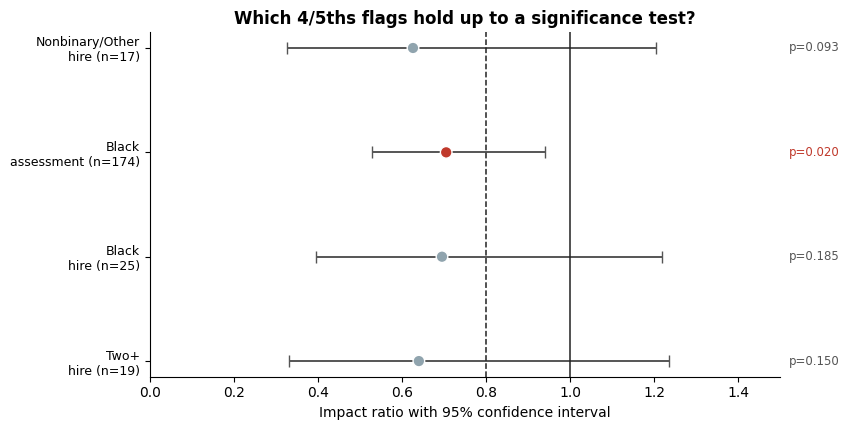

In [9]:
# Forest plot: impact ratio with 95% CI per flagged cell, the 0.80 screening line and the
# 1.00 parity line. Whether a CI crosses 1.00 is the visual test for statistical reliability.
fig, ax = plt.subplots(figsize=(8.6,4.4))
yy=range(len(inf))
ax.errorbar(inf.impact_ratio, list(yy),
            xerr=[inf.impact_ratio-inf.ci_low, inf.ci_high-inf.impact_ratio],
            fmt="none", ecolor="#555", elinewidth=1.4, capsize=4, zorder=1)
ax.scatter(inf.impact_ratio, list(yy),
           c=["#c0392b" if s else "#90a4ae" for s in inf.significant_05],
           s=70, zorder=2, edgecolor="white")
ax.axvline(1.0, color="#222", lw=1.1); ax.axvline(0.8, color="#222", ls="--", lw=1.1)
ax.set_yticks(list(yy))
ax.set_yticklabels([f"{r.group}\n{r.stage} (n={r.n})" for r in inf.itertuples()], fontsize=9)
ax.set_xlim(0,1.5); ax.set_xlabel("Impact ratio with 95% confidence interval")
ax.set_title("Which 4/5ths flags hold up to a significance test?", fontweight="bold")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.invert_yaxis()
for yi,r in zip(yy, inf.itertuples()):
    ax.text(1.52, yi, f"p={r.p_value:.3f}", va="center", fontsize=8.5,
            color="#c0392b" if r.significant_05 else "#555")
plt.tight_layout(); plt.show()

Three of the four intervals cross 1.00 (the hire-stage flags, all n<30, p>.09) — not distinguishable
from parity. Only the **assessment-stage Black** cell has an interval entirely below 1.00 (ratio 0.70,
95% CI [0.53, 0.94], *p* = .020): the one flag the evidence supports as a real gap.

## Takeaways

The funnel and the fairness screen converge on the **assessment** gate: it filters the largest share
of the pipeline and is the only early stage where a subgroup falls below the 4/5ths threshold on a
reliable sample (Black candidates, impact ratio 0.70, n = 174). The hire-stage flags rest on fewer
than 30 candidates and are logged as provisional. Next steps — job-relatedness evidence, cut-score
sensitivity analysis, and minimum-n guardrails — are detailed in `02_Project_Report.md`.